# Bài tập lớn 1 — Biểu diễn ảnh màu, lọc ảnh và biến đổi hình học

**Môn:** Xử lý ảnh và Thị giác máy tính  
**Nhóm:** ...  
**Thành viên:** ...  

---


# 1. Mô tả bài toán & mục tiêu

## 1.1. Mô tả bài toán
- ...

## 1.2. Input
- 2–3 ảnh màu có đặc điểm khác nhau.
- ...

## 1.3. Output
- Ảnh RGB / Grayscale / các kênh màu.
- Ảnh sau filtering.
- Ảnh sau geometric transformation.

## 1.4. Mục tiêu
- Hiểu cách biểu diễn ảnh màu và ảnh xám.
- Hiểu vai trò của các kênh R, G, B.
- Hiểu low-pass và high-pass filtering.
- Hiểu các phép biến đổi hình học cơ bản.
- So sánh Affine và Projective Transformation.


# 2. Cơ sở lý thuyết

## 2.1. Color Image Representation

### 2.1.1. RGB Image
- ...

### 2.1.2. Grayscale Image
- ...

### 2.1.3. Color Channels
- R channel
- G channel
- B channel

### 2.1.4. RGB → Grayscale
- Công thức:
- Giải thích:


## 2.2. Image Filtering

### 2.2.1. Kernel và Convolution
- ...

### 2.2.2. Low-pass Filter
- Mean Filter
- Gaussian Filter

### 2.2.3. High-pass Filter
- Sobel Filter
- Laplacian Filter


## 2.3. Geometric Transformation

### 2.3.1. Translation
- ...

### 2.3.2. Rotation
- ...

### 2.3.3. Scaling
- ...

### 2.3.4. Affine Transformation
- ...

### 2.3.5. Projective Transformation / Homography
- ...

### 2.3.6. Affine vs Projective
- ...


# 3. Hiện thực

## 3.1. Công cụ sử dụng
- Python
- NumPy
- OpenCV
- Matplotlib
- Jupyter Notebook / Google Colab

## 3.2. Pipeline tổng thể
- ...

## 3.3. Color Processing
- RGB → Grayscale
- Tách R, G, B
- Ghép lại ảnh
- Thay đổi / hoán đổi channel



### 3.3.1. Chuẩn bị thư viện và ảnh

In [2]:
%pip install numpy opencv-python matplotlib

  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 2.5 MB/s eta 0:00:002.9 MB/s eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 MB 2.3 MB/s eta 0:00:00m eta 0:00:010:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 1.2 MB/s eta 0:00:000:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 1.1 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 785.3 kB/s eta 0:00:00 kB/s eta 0:00:01:01
Using cached pyparsing-3.3.3-py3-none-any.whl (126 kB)

[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
assignment_dir = Path.cwd().parent
images_dir = assignment_dir / "images"
images_dir.mkdir(parents=True, exist_ok=True)

/Users/minhman/Downloads/Workspace/ComputerVision/IPCV-261/assignment_1/notebook


Kích thước: (600, 800, 3)
Kiểu dữ liệu: uint8


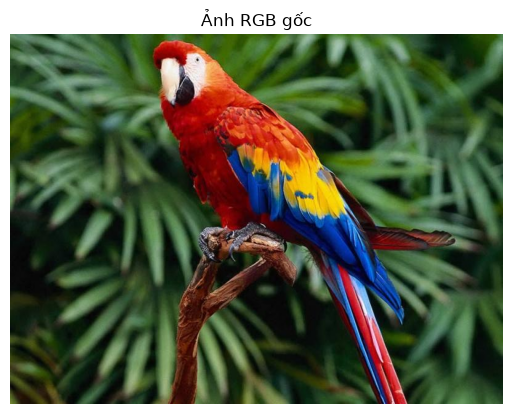

In [ ]:
image_path = images_dir / "image_01.jpg"
url = "https://toplist.vn/images/800px/vet-do-duoi-dai-vet-hong-14024.jpg"

!wget -O "{image_path}" "{url}"

bgr = cv2.imread(str(image_path))

if bgr is None:
    raise FileNotFoundError(f"Không đọc được ảnh: {image_path}")

# OpenCV đọc ảnh theo thứ tự BGR; chuyển thành RGB để xử lý và hiển thị.
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

print("Kích thước:", rgb.shape)
print("Kiểu dữ liệu:", rgb.dtype)

plt.imshow(rgb)
plt.title("Ảnh RGB gốc")
plt.axis("off")
plt.show()

### 3.3.2. Chuyển RGB -> ảnh xám -> RGB

RGB gốc: (600, 800, 3)
Ảnh xám: (600, 800)
Ảnh xám dạng RGB: (600, 800, 3)


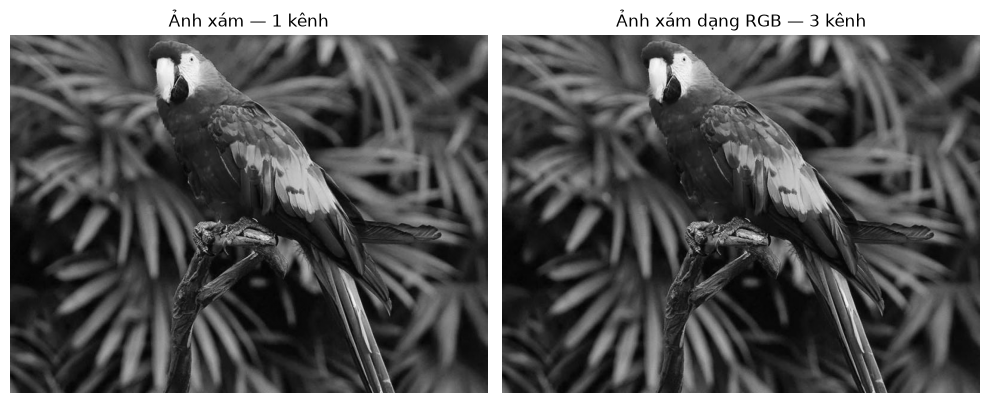

In [10]:
# Chuyển sang số thực trước khi tính toán.
rgb_float = rgb.astype(np.float32)

gray = (
    0.299 * rgb_float[:, :, 0]
    + 0.587 * rgb_float[:, :, 1]
    + 0.114 * rgb_float[:, :, 2]
)

gray = np.clip(np.rint(gray), 0, 255).astype(np.uint8)

# Lặp lại ảnh xám trên cả ba kênh.
gray_rgb = np.stack([gray, gray, gray], axis=-1)

print("RGB gốc:", rgb.shape)           # (H, W, 3)
print("Ảnh xám:", gray.shape)          # (H, W)
print("Ảnh xám dạng RGB:", gray_rgb.shape)  # (H, W, 3)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Ảnh xám — 1 kênh")

axes[1].imshow(gray_rgb)
axes[1].set_title("Ảnh xám dạng RGB — 3 kênh")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


### 3.3.3. Tách từng kênh màu

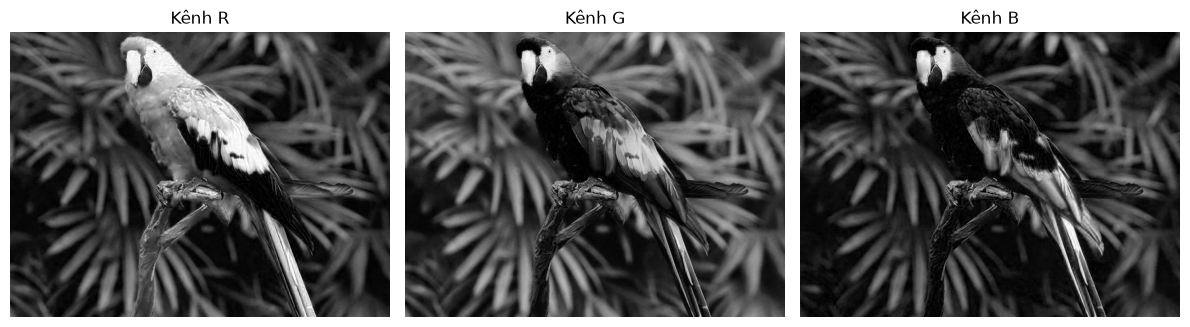

In [11]:
R = rgb[:, :, 0]
G = rgb[:, :, 1]
B = rgb[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, channel, name in zip(
    axes,
    [R, G, B],
    ["Kênh R", "Kênh G", "Kênh B"],
):
    ax.imshow(channel, cmap="gray", vmin=0, vmax=255)
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

### 3.3.4. Ghép lại ảnh màu gốc

Ảnh ghép giống hoàn toàn ảnh gốc: True


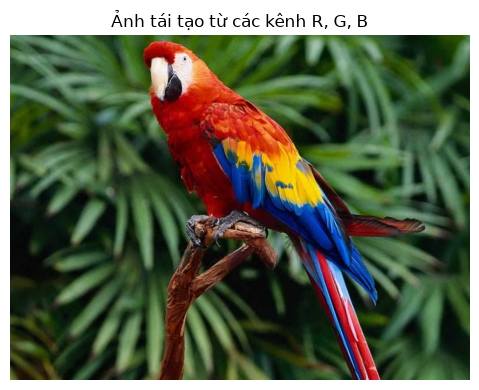

In [12]:
reconstructed = np.stack([R, G, B], axis=-1)

same = np.array_equal(rgb, reconstructed)
print("Ảnh ghép giống hoàn toàn ảnh gốc:", same)

assert same, "Ghép kênh chưa đúng"

plt.figure(figsize=(6, 4))
plt.imshow(reconstructed)
plt.title("Ảnh tái tạo từ các kênh R, G, B")
plt.axis("off")
plt.tight_layout()
plt.show()


### 3.3.5. Tạo ảnh màu mới

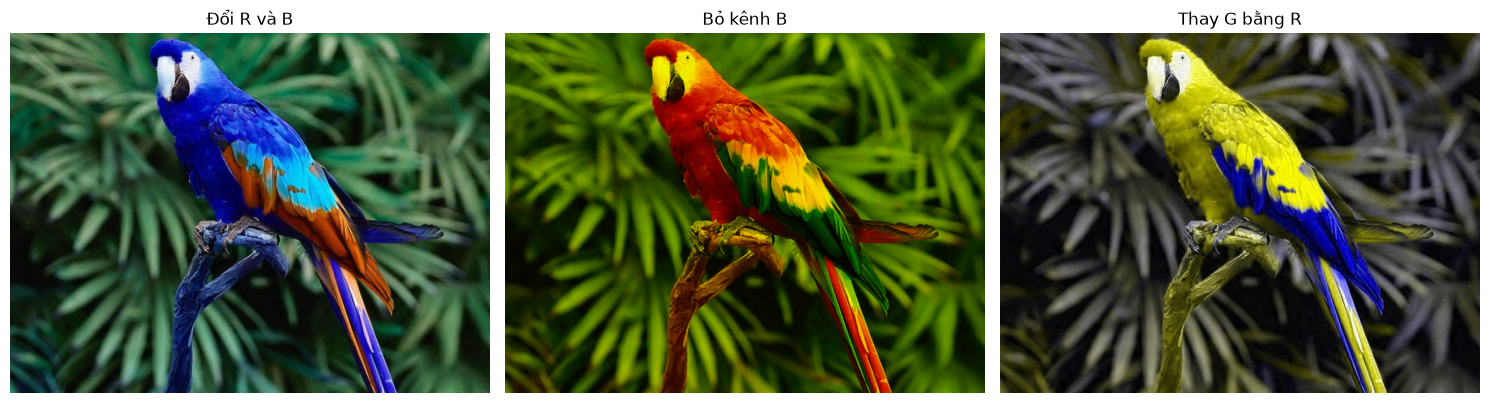

In [13]:
# Thí nghiệm 1: đổi vị trí R và B.
swapped = np.stack([B, G, R], axis=-1)

# Thí nghiệm 2: loại bỏ thành phần B.
zero = np.zeros_like(B)
no_blue = np.stack([R, G, zero], axis=-1)

# Thí nghiệm 3: thay kênh G bằng kênh R.
replace_green = np.stack([R, R, B], axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

experiments = [
    ("Đổi R và B", swapped),
    ("Bỏ kênh B", no_blue),
    ("Thay G bằng R", replace_green),
]

for ax, (title, image) in zip(axes, experiments):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


### 3.3.6. Kết quả

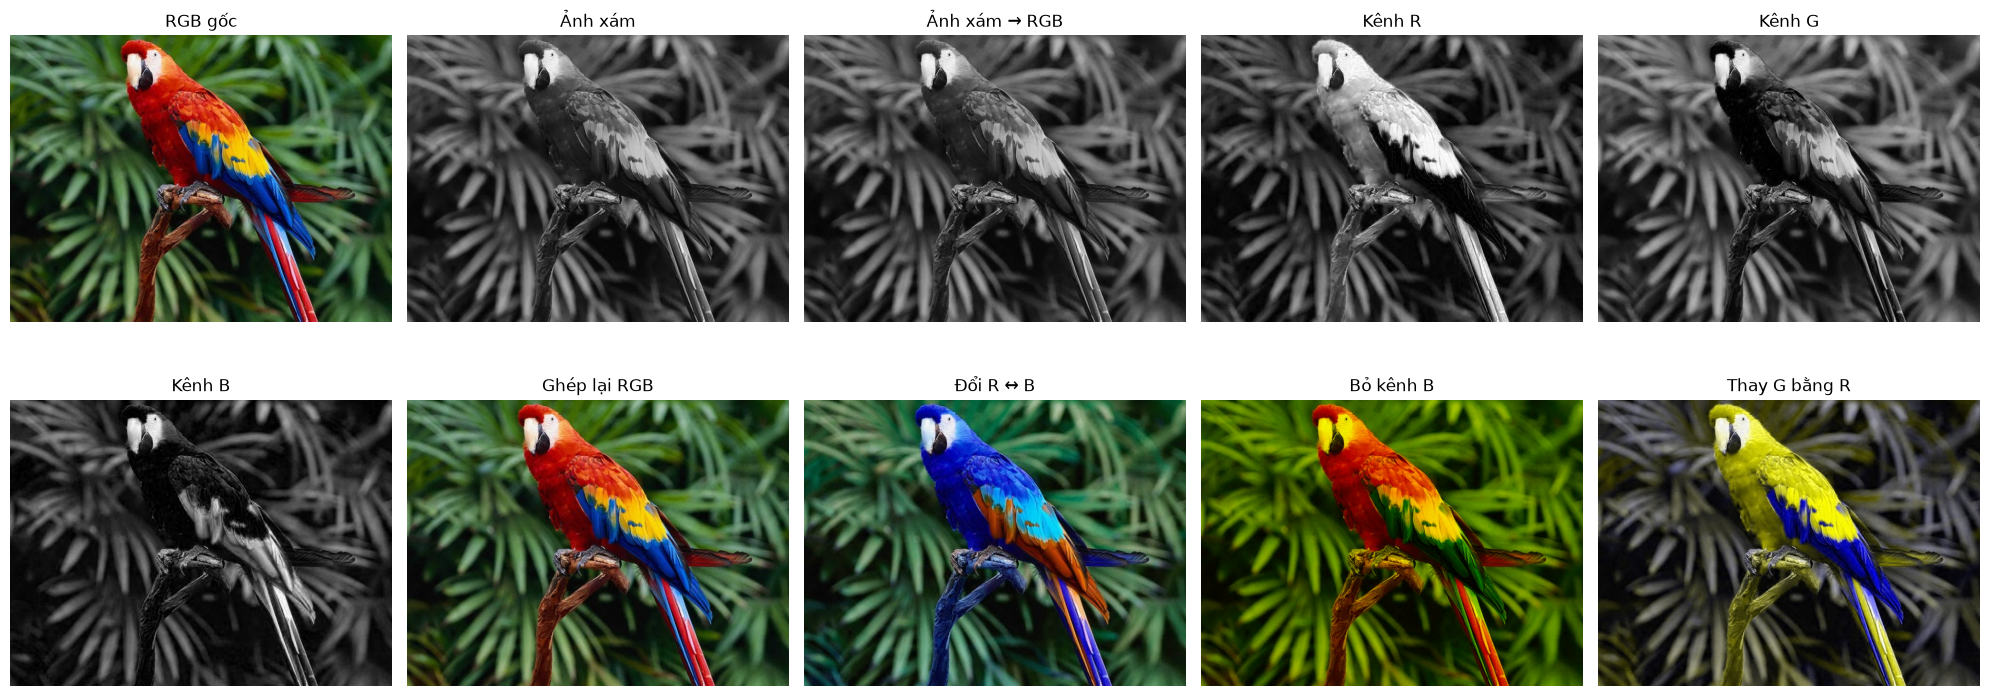

In [14]:
results = [
    ("RGB gốc", rgb),
    ("Ảnh xám", gray),
    ("Ảnh xám → RGB", gray_rgb),
    ("Kênh R", R),
    ("Kênh G", G),
    ("Kênh B", B),
    ("Ghép lại RGB", reconstructed),
    ("Đổi R ↔ B", swapped),
    ("Bỏ kênh B", no_blue),
    ("Thay G bằng R", replace_green),
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, (title, img) in zip(axes.flat, results):
    if img.ndim == 2:
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    else:
        ax.imshow(img)

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3.4. Image Filtering
- Mean Filter
- Gaussian Filter
- Sobel Filter
- Laplacian Filter

## 3.5. Geometric Transformation
- Translation
- Rotation
- Scaling
- Affine
- Projective


# 4. Kết quả thực nghiệm

## 4.1. Experiment 1 — Color Representation
- Original RGB
- Grayscale
- R / G / B channels
- Reconstructed image
- Modified / swapped channels

### Nhận xét

**Chuyển đổi ảnh màu và ảnh xám**

- **RGB → ảnh xám:** Gộp ba thành phần R, G, B thành một mức xám theo tổng có trọng số $Y = 0.299R + 0.587G + 0.114B$ ([nguồn OpenCV](https://docs.opencv.org/4.11.0/de/d25/imgproc_color_conversions.html)). Với ảnh 8 bit, kết quả được làm tròn và lưu trong khoảng 0–255.
- **Ảnh xám → RGB:** Sao chép mức xám thành ba thành phần $(Y, Y, Y)$. Dữ liệu chuyển từ một kênh sang ba kênh bằng nhau, không khôi phục thông tin màu ban đầu.

**Sự khác biệt về mặt trực quan khi thay đổi hoặc thiếu kênh màu**

Trên ảnh con vẹt ở mục Color Processing:

| Thí nghiệm | Nhận xét trực quan |
|---|---|
| Đổi R và B | Ngực đỏ thành xanh dương, lông xanh dương thành đỏ–cam, dải vàng thành xanh lơ. |
| Bỏ B | Lông xanh dương tối đi và chuyển xanh lá sẫm; mặt gần trắng thành vàng. |
| Thay G bằng R | Ngực đỏ thành vàng; nền lá giảm sắc xanh lá; lông xanh dương vẫn xanh đậm. |



## 4.2. Experiment 2 — Low-pass Filtering

### Mean Filter
- Kernel 3×3
- Kernel 5×5
- Kernel 7×7

### Gaussian Filter
- Kernel 3×3
- Kernel 5×5
- Kernel 7×7

### Nhận xét
- ...


## 4.3. Experiment 3 — High-pass Filtering

### Sobel
- Sobel X
- Sobel Y
- Sobel Magnitude

### Laplacian
- ...

### Nhận xét
- ...


## 4.4. Experiment 4 — Basic Geometric Transformations

- Translation
- Rotation
- Scaling

### Nhận xét
- ...


## 4.5. Experiment 5 — Affine vs Projective

### Affine Transformation
- ...

### Projective Transformation
- ...

### So sánh
- Parallel lines
- Perspective
- Shape distortion

### Nhận xét
- ...


# 5. Nhận xét & thảo luận

## 5.1. Color Representation

- Ảnh thay đổi thế nào khi mất hoặc thay đổi channel?

Màu ảnh thay đổi do sự kết hợp R, G, B tại mỗi pixel bị thay đổi; độ sáng cảm nhận và tương phản cũng có thể thay đổi. Trên ảnh con vẹt, đổi R/B làm ngực đỏ thành xanh dương; bỏ B làm lông xanh tối đi; thay G bằng R làm ngực đỏ thành vàng. Mức ảnh hưởng phụ thuộc vào giá trị kênh tại từng vùng ảnh.

- Vì sao RGB → Grayscale làm mất thông tin màu?

Phép chuyển đổi gộp ba giá trị R, G, B thành một mức xám. Nhiều bộ RGB khác nhau có thể cho cùng mức xám, nên không thể xác định duy nhất màu ban đầu chỉ từ ảnh xám. Ngoài ra sao chép mức xám thành ba kênh chỉ tạo bộ (Y, Y, Y), không khôi phục thông tin màu đã mất.

## 5.2. Low-pass Filtering
- Mean và Gaussian khác nhau thế nào?
- Kernel size ảnh hưởng thế nào đến blur và noise?

## 5.3. High-pass Filtering
- Sobel và Laplacian khác nhau thế nào?
- Noise ảnh hưởng thế nào đến edge detection?

## 5.4. Geometric Transformation
- Rotation / Scaling ảnh hưởng chất lượng ảnh thế nào?

## 5.5. Affine vs Projective
- Khi nào dùng Affine?
- Khi nào dùng Projective?
- Các trường hợp hoạt động tốt / chưa tốt.


# 6. Kết luận & hướng phát triển

## 6.1. Kết luận
- ...

## 6.2. Hạn chế
- ...

## 6.3. Hướng phát triển
- Thử thêm Median / Bilateral Filter.
- Đánh giá bằng PSNR / SSIM.
- Tự động xác định điểm cho Homography.
- Xây dựng demo Document Scanner.


# Phân công công việc

| Thành viên | Phần phụ trách |
|---|---|
| Member 1 | RGB, Gray, Channels, Reconstruction |
| Member 2 | Mean Filter, Gaussian Filter |
| Member 3 | Sobel, Laplacian, Translation, Rotation, Scaling |
| Member 4 | Affine, Projective / Homography, Comparison |
